# Adversarial Signal Decomposition and Selective Debiasing Pilot

## 1. Research Question

**Fixed case:** context C = "baseball bat", target T = "sports ball", model = `llava-hf/llava-1.5-7b-hf`.

- **Question A (signal decomposition feasibility):** does the representation shift induced by a targeted
  adversarial attack contain a separable component that selectively supports the spurious
  baseball-bat -> sports-ball hallucination effect?
- **Question B (method feasibility):** if such a component exists, can we train the model to suppress
  it and obtain *better selective* functional debiasing than simple clean/adversarial fine-tuning?

This notebook only loads already-saved outputs -- it does not rerun PGD, hidden-state extraction, LoRA
training, or model evaluation.

## 2. Prior Negative Result

Stage 11 Exp6 (`CooccurrenceHallucinationDiagnostic/scripts/run_stage11_exp6_causal_intervention.py`)
subtracted a single fixed Layer-19 direction (diff-in-means, original vs. bat-removed) from every
position's hidden state. Result: reduction in unsupported Ball evidence (0.257) was **essentially the
same size** as the reduction in genuine Ball evidence (0.275/0.256) and Bat recognition (0.320, actually
larger) -- classified **non-selective**. This pilot asks whether decomposing the shift into multiple
components (rather than assuming one mean direction) can recover a more selective candidate.

## 3. Pilot Dataset

Reused verbatim from `adversarial_functional_debiasing_pilot` (same seed=42 split, same 4 disjoint COCO groups). See `audit/repository_audit.md`.

In [1]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

manifest = pd.read_csv(OUT / "data" / "sample_manifest.csv")
manifest.groupby(["fold", "role"])["image_id"].nunique()


fold   role             
test   G00                  25
       G10                  20
       GC                   20
       GT                   25
train  G10_forget           45
       GC_context_retain    45
       GT_target_retain     45
Name: image_id, dtype: int64

## 4. Adversarial Exposure

Existing PGD attack (epsilon=16/255), reused unchanged.

N=45  attack_success_rate=1.000
mean clean_s_ball=-0.4240  mean adv_s_ball=1.0531  mean delta_s_ball=1.4771


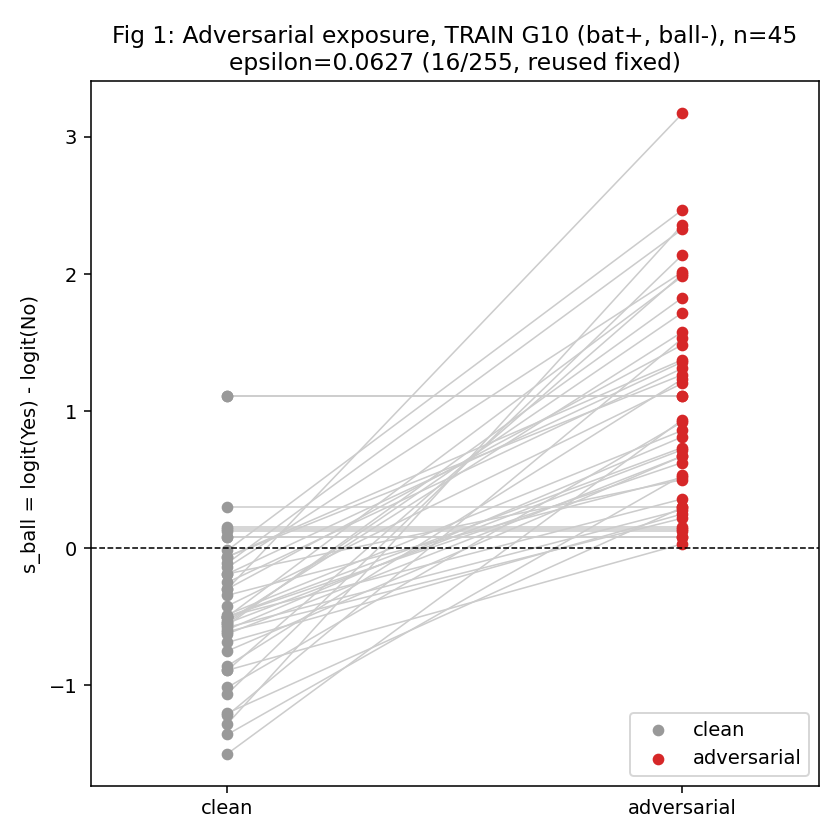

In [2]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

adv = pd.read_csv(OUT / "data" / "adversarial_forget_set.csv")
print(f"N={len(adv)}  attack_success_rate={adv.attack_success.mean():.3f}")
print(f"mean clean_s_ball={adv.clean_s_ball.mean():.4f}  mean adv_s_ball={adv.adv_s_ball.mean():.4f}  mean delta_s_ball={adv.delta_s_ball.mean():.4f}")
display(Image(filename=str(OUT / "figures" / "fig1_adversarial_exposure.png")))


## 5. Layer-19 Representation Shift

`delta_h = h_adv - h_clean` at Layer 19 (last teacher-forced decision-token position), for every TRAIN G10 image.

In [3]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

import torch
cached = torch.load(OUT / "cached_activations" / "layer19_delta_h.pt")
meta = pd.read_csv(OUT / "cached_activations" / "layer19_metadata.csv")
print(f"delta_h shape: {tuple(cached['delta_h'].shape)}  layer_idx={cached['layer_idx']}")
print(f"mean ||delta_h||: {cached['delta_h'].norm(dim=1).mean().item():.4f}")
meta.describe()


delta_h shape: (45, 4096)  layer_idx=19
mean ||delta_h||: 11.3276


,image_id,clean_s_ball,adv_s_ball,delta_s_ball,hidden_dim
count,45.000000,45.000000,45.000000,45.000000,45.0
mean,293509.711111,-0.423958,1.053125,1.477083,4096.0
std,152367.191300,0.548785,0.775915,0.987187,0.0
min,2153.000000,-1.500000,0.031250,0.000000,4096.0
25%,182021.000000,-0.687500,0.359375,0.859375,4096.0
50%,276804.000000,-0.500000,0.921875,1.421875,4096.0
75%,427256.000000,-0.109375,1.531250,2.156250,4096.0
max,559348.000000,1.109375,3.171875,3.640625,4096.0


## 6. PCA/SVD Decomposition

Fit on the DEV portion (70%) of TRAIN G10 delta_h only. PC1 is not assumed spurious merely because it explains the most variance -- see Section 7.

,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.565648,0.565648
1,PC2,0.101604,0.667253
2,PC3,0.075807,0.743060
3,PC4,0.061330,0.804390
4,PC5,0.037493,0.841883
5,PC6,0.026762,0.868645
6,PC7,0.022618,0.891263
7,PC8,0.017915,0.909178
8,PC9,0.014745,0.923923
9,PC10,0.014178,0.938101


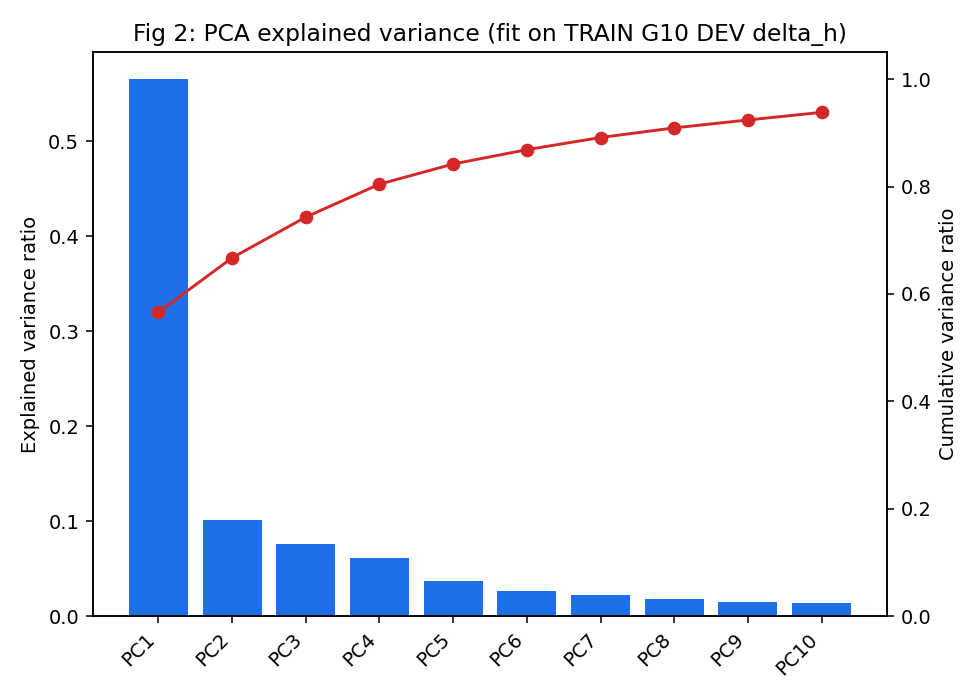

In [4]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

ev = pd.read_csv(OUT / "decomposition" / "explained_variance.csv")
display(ev)
display(Image(filename=str(OUT / "figures" / "fig2_explained_variance.png")))


## 7. Component Functional Selectivity

Projection intervention `h' = h - lambda*proj_u(h)` at Layer 19, lambda in {0.5, 1.0}, evaluated on the internal VAL split (never on the final CLEAN TEST split).

,candidate_type,candidate_id,lambda,delta_spurious,delta_target,delta_context,selectivity,n_g10,n_gt,n_gc
0,pca_component,PC1,0.5,0.705357,-0.748884,-1.697545,-1.741071,14,14,14
1,pca_component,PC1,1.0,1.387277,-1.468750,-3.300223,-3.381696,14,14,14
2,pca_component,PC2,0.5,0.034598,0.094866,0.190848,-0.251116,14,14,14
3,pca_component,PC2,1.0,0.064732,0.198661,0.391741,-0.525670,14,14,14
4,pca_component,PC3,0.5,-0.026786,-0.036830,-0.045759,-0.055804,14,14,14
5,pca_component,PC3,1.0,-0.050223,-0.071429,-0.080357,-0.101562,14,14,14
6,pca_component,PC4,0.5,0.000000,0.102679,0.082589,-0.185268,14,14,14
7,pca_component,PC4,1.0,-0.012277,0.217634,0.175223,-0.380580,14,14,14
8,pca_component,PC5,0.5,0.000000,0.132812,0.157366,-0.290179,14,14,14
9,pca_component,PC5,1.0,0.001116,0.290179,0.335938,-0.625000,14,14,14


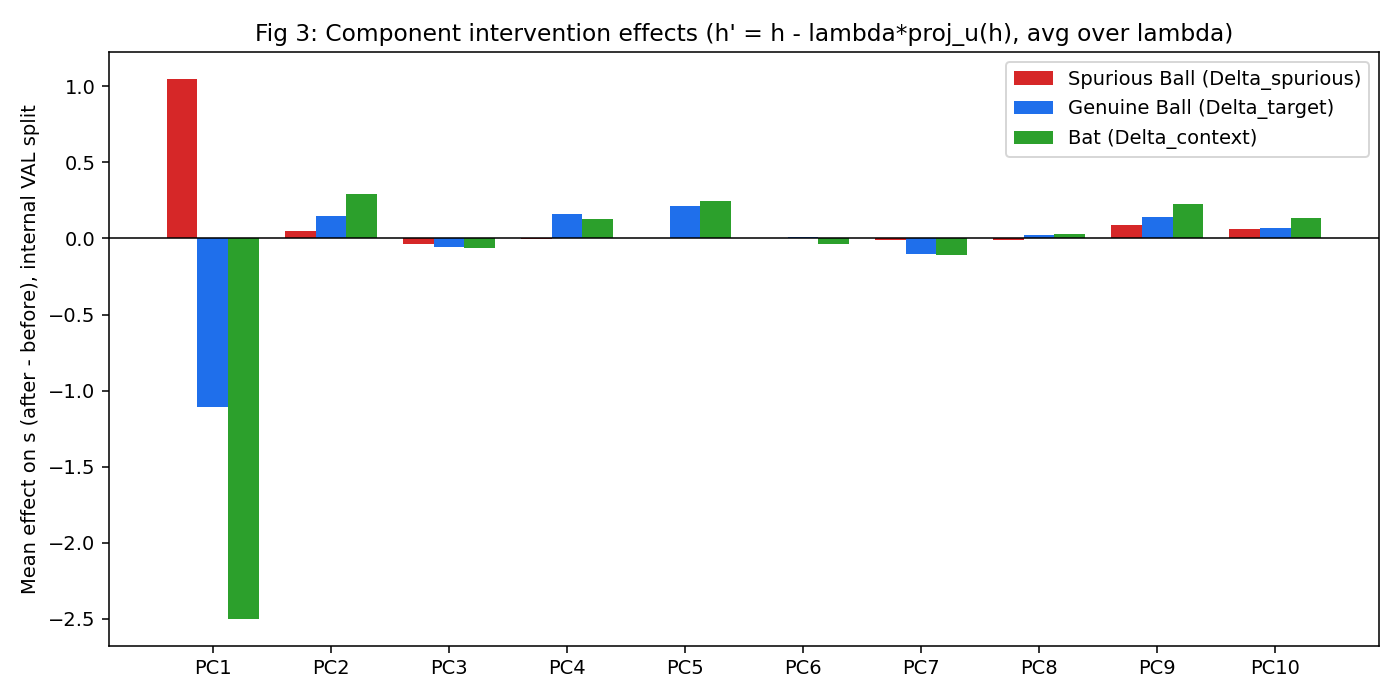

In [5]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

interv = pd.read_csv(OUT / "component_intervention" / "intervention_results.csv")
display(interv)
display(Image(filename=str(OUT / "figures" / "fig3_component_selectivity.png")))


## 8. Mean Direction and Random-Direction Baselines

In [6]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

mean_dir = pd.read_csv(OUT / "component_intervention" / "mean_direction_results.csv")
random_dir = pd.read_csv(OUT / "component_intervention" / "random_direction_results.csv")
print("Mean direction:"); display(mean_dir)
print(f"Random directions (n={random_dir.candidate_id.nunique()}): selectivity range "
      f"[{random_dir.selectivity.min():.4f}, {random_dir.selectivity.max():.4f}]")


Mean direction:


,candidate_type,candidate_id,lambda,delta_spurious,delta_target,delta_context,selectivity,n_g10,n_gt,n_gc
0,mean_direction,mean,0.5,0.65625,-0.732143,-1.570312,-1.646205,14,14,14
1,mean_direction,mean,1.0,1.28125,-1.469866,-3.122768,-3.311384,14,14,14


Random directions (n=20): selectivity range [-0.0190, 0.0056]


## 9. Best Component

Ranked by `Selectivity_k = |Delta_spurious| - |Delta_target| - |Delta_context|`, minimum over the two lambda values (must be selective at both), on the internal VAL split -- selection never touches the final CLEAN TEST split.

,candidate_type,candidate_id,selectivity_min_over_lambda,mean_delta_spurious,mean_delta_target,mean_delta_context
0,random_direction,random_13,0.003348,0.013393,0.004464,0.004464
1,random_direction,random_9,0.000000,-0.006138,-0.002232,-0.000558
2,random_direction,random_18,0.000000,0.006696,-0.001116,0.005022
3,random_direction,random_11,-0.003348,0.007812,0.001116,0.008929
4,random_direction,random_16,-0.003348,0.011161,0.002790,0.009487
5,random_direction,random_8,-0.005580,0.003348,-0.006138,-0.001674
6,random_direction,random_19,-0.005580,0.002790,0.000558,0.005580
7,random_direction,random_20,-0.005580,0.006696,-0.003348,-0.005580
8,random_direction,random_2,-0.006696,0.005580,-0.003906,-0.004464
9,random_direction,random_5,-0.006696,-0.001674,-0.001116,0.006696


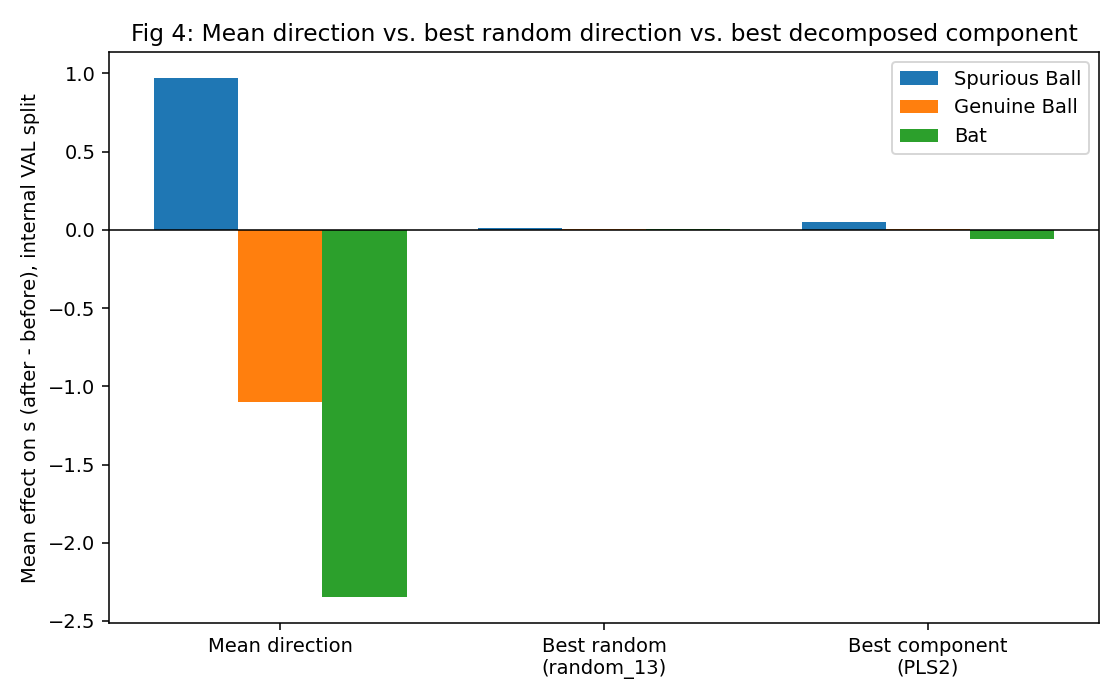

In [7]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

sel = pd.read_csv(OUT / "decomposition" / "component_selectivity.csv")
display(sel)
display(Image(filename=str(OUT / "figures" / "fig4_mean_vs_best_component.png")))


## 10. Clean Debias vs. Adv Debias

Models A and B, reused verbatim from `adversarial_functional_debiasing_pilot` (identical checkpoints, identical clean-test evaluation).

In [8]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

summary = pd.read_csv(OUT / "evaluation" / "summary.csv")
display(summary[summary.method.isin(["original", "clean_debias", "adv_debias"])])


,method,coupling_B,g10_s_ball_mean,ball_plus_acc,bat_plus_acc,delta_coupling_B_from_original,delta_ball_plus_acc_from_original,delta_bat_plus_acc_from_original
0,original,1.936875,-0.087500,0.88,0.95,0.000000,0.00,0.00
1,clean_debias,0.320469,-0.425781,0.92,1.00,-1.616406,0.04,0.05
2,adv_debias,-0.182344,-0.486719,0.84,1.00,-2.119219,-0.04,0.05


## 11. Adv + Decomp Debias

Model C -- the only newly trained LoRA adapter in this pilot.

In [9]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

train_cfg = json.loads((OUT / "adv_decomp_debias" / "training_config.json").read_text())
print(json.dumps(train_cfg, indent=2))
train_log = pd.read_csv(OUT / "adv_decomp_debias" / "train_log.csv")
train_log.tail()


{
  "variant": "adv_decomp",
  "model_id": "llava-hf/llava-1.5-7b-hf",
  "seed": 42,
  "layer_idx": 19,
  "selected_component": {
    "candidate_type": "pls_component",
    "candidate_id": "PLS2",
    "selectivity_min_over_lambda": -0.015624999999999993,
    "beats_mean_direction": true,
    "beats_best_random_direction": false
  },
  "loss_mode": "spur_plus_adv_no",
  "lambda_spur": 1.0,
  "lambda_target_retain": 1.0,
  "lambda_context_retain": 1.0,
  "lora": {
    "target_modules": [
      "q_proj",
      "v_proj"
    ],
    "r": 16,
    "alpha": 32,
    "dropout": 0.05,
    "learning_rate": 0.0001,
    "num_epochs": 3,
    "batch_size": 1,
    "gradient_accumulation_steps": 4
  },
  "target_modules_resolved_count": 64,
  "trainable_params": 8388608,
  "total_params": 7071815680,
  "trainable_pct": 0.11862028621198453,
  "n_forget_pairs": 45,
  "n_retain_target": 45,
  "n_retain_context": 45,
  "n_epochs": 3,
  "gradient_accumulation_steps": 4,
  "n_optimizer_steps": 33
}


,epoch,step,global_step,loss_spur,loss_adv_no,loss_target_retain,loss_context_retain,loss_total
130,2,40,131,0.035248,0.658069,0.414193,0.303940,1.411450
131,2,41,132,0.007229,0.494272,0.837992,0.142208,1.481701
132,2,42,133,0.003178,0.519052,0.834210,0.011654,1.368093
133,2,43,134,0.002018,0.519744,0.717135,0.011533,1.250429
134,2,44,135,0.593750,0.677133,0.709956,0.048000,2.028839


## 12. Functional Coupling B

`B = E[s_ball | Bat+, Ball-] - E[s_ball | Bat-, Ball-]`, all four models, unseen CLEAN test images.

,method,coupling_B,delta_coupling_B_from_original
0,original,1.936875,0.000000
1,clean_debias,0.320469,-1.616406
2,adv_debias,-0.182344,-2.119219
3,adv_decomp_debias,0.283438,-1.653437


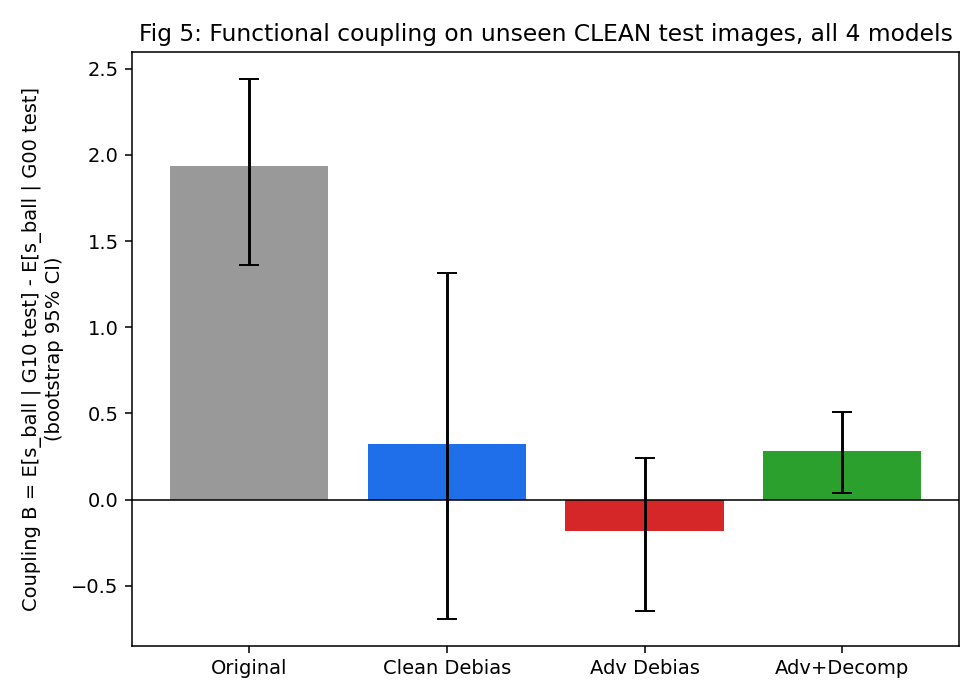

In [10]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

display(summary[["method", "coupling_B", "delta_coupling_B_from_original"]])
display(Image(filename=str(OUT / "figures" / "fig5_coupling_by_method.png")))


## 13. Genuine Ball Retention (GT, Ball+)

In [11]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

display(summary[["method", "ball_plus_acc", "delta_ball_plus_acc_from_original"]])


,method,ball_plus_acc,delta_ball_plus_acc_from_original
0,original,0.88,0.00
1,clean_debias,0.92,0.04
2,adv_debias,0.84,-0.04
3,adv_decomp_debias,0.72,-0.16


## 14. Bat Retention (GC, Bat+)

,method,bat_plus_acc,delta_bat_plus_acc_from_original
0,original,0.95,0.00
1,clean_debias,1.00,0.05
2,adv_debias,1.00,0.05
3,adv_decomp_debias,1.00,0.05


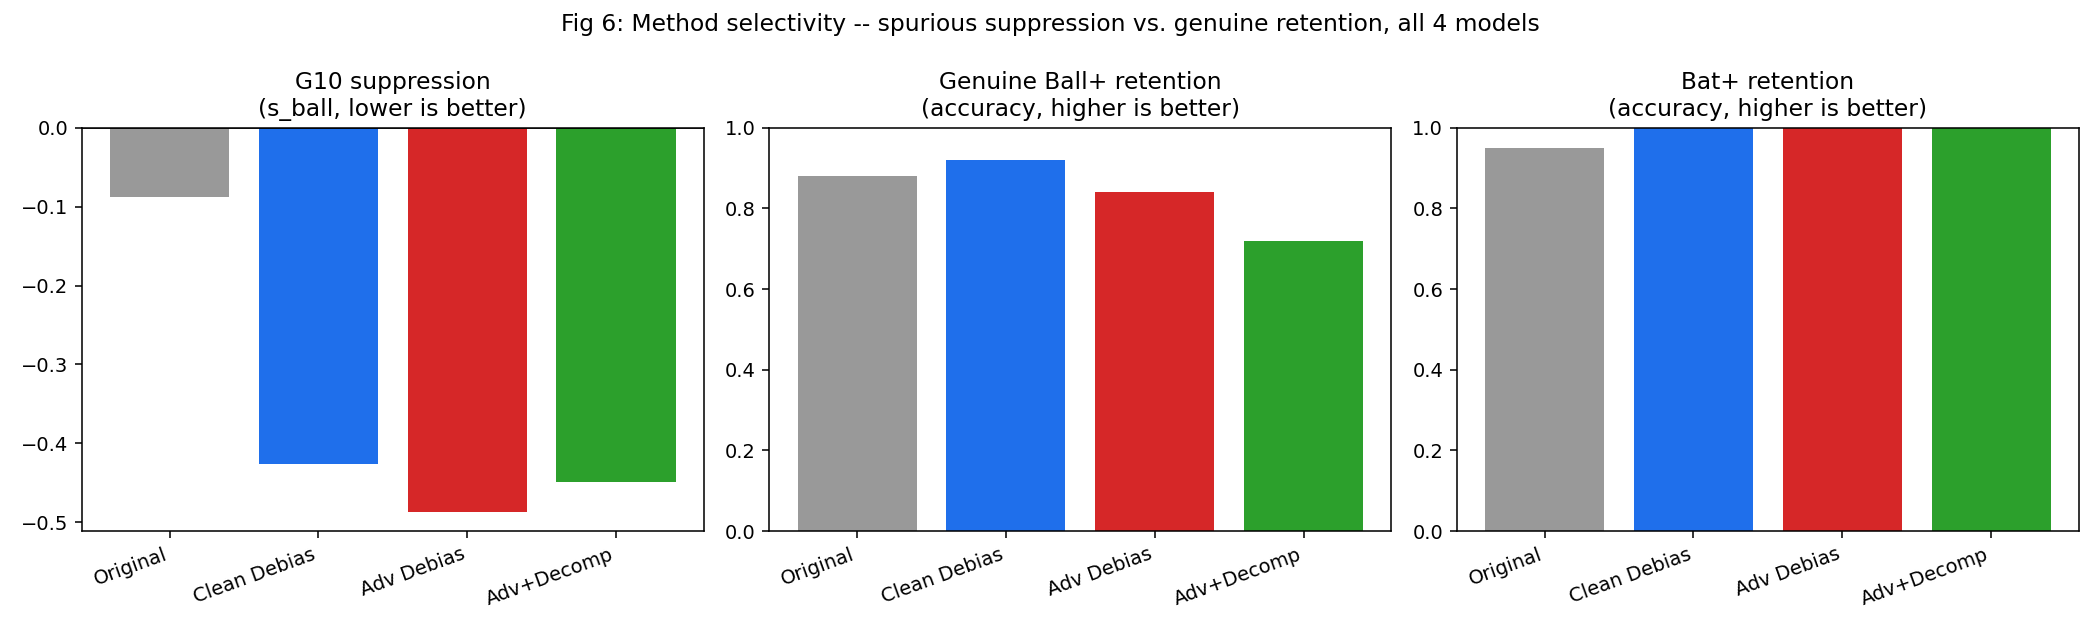

In [12]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

display(summary[["method", "bat_plus_acc", "delta_bat_plus_acc_from_original"]])
display(Image(filename=str(OUT / "figures" / "fig6_method_selectivity.png")))


## 15. GO / NO-GO Decision

In [13]:
import csv, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

OUT = Path("/data3/KJE/code/UQ/outputs/adversarial_signal_debiasing_pilot")

stats = json.loads((OUT / "evaluation" / "statistics.json").read_text())
print("Component selectivity summary:", json.dumps(stats["component_selectivity_summary"], indent=2))
print("\nDecision:", stats["go_no_go"]["decision"])


Component selectivity summary: {
  "available": true,
  "best_component": "pls_component:PLS2",
  "best_selectivity": -0.015624999999999993,
  "mean_direction_selectivity": -3.311383928571429,
  "best_random_selectivity": 0.003348214285714286,
  "beats_mean_direction": true,
  "beats_best_random_direction": false,
  "decomposition_isolates_selective_component": false
}

Decision: NO-GO A: no separable component -- the best PCA/PLS component does not clearly beat the mean-direction and random-direction baselines on the internal VAL selectivity test


## 16. Limitations

- Single pair (baseball bat -> sports ball), single model (LLaVA-1.5-7B), single layer (19) -- a feasibility
  pilot, not a general result.
- Component selection used an internal 30% VAL split carved from TRAIN (n=14 per group) -- small, so
  selectivity estimates are noisy; see bootstrap CIs where reported.
- The `Selectivity_k` ranking metric can favor a direction that changes *nothing* (near-zero effect on all
  three groups) over one that changes something with partial selectivity, since both minimize
  `|target|+|context|` but the former also minimizes `|spurious|` trivially. Random directions with
  near-zero effect can therefore rank above real components -- read the raw `Delta_spurious` /
  `Delta_target` / `Delta_context` columns, not just the ranking, before concluding a component is useful.
- PLS was run only because PCA showed weak/poor selectivity (Part VIII's conditional trigger), per the
  pilot's pre-specified decision rule, not as post-hoc tuning.
- No causal claim beyond correlation-plus-intervention at one layer, one token position.

## 17. Next Step

See `README.md`'s "Next Step" section for the concrete recommendation conditioned on the GO/NO-GO decision
reached above.